# Plotting grid statistics of a PLZ

This notebook plots statistics of all grids of a postcode area: transformer sizes, cable types and lengths, grid parameters per transformer size and the transformers on a map.

**Prerequisites**

- pylovo installed with the `notebooks` extra (`uv sync --extra notebooks`) and this notebook running on the kernel of the project environment (`.venv`), see `notebook_tutorials/README.md`.
- A `.env` in the repository root that points to your pylovo database, a completed `pylovo-setup` and generated grids for the postcode area (PLZ) below, e.g. `pylovo-generate --plz 85653`.
- Grids are read for the `VERSION_ID` of `config/config_generation.yaml`.
- The PLZ analysis in `pylovo.plz_parameters`. It runs after the grid generation if `ANALYZE_GRIDS: True` in `config/config_generation.yaml`; otherwise run `pylovo-analyze --plz <PLZ>`.

The stored outputs were generated for the demo postcode area 85653 (Aying), whose buildings, streets and transformers are derived from OpenStreetMap. Map data © OpenStreetMap contributors (ODbL).

In [1]:
# Parameters
plz = 85653  # postcode area with generated and analysed grids

## Setup

In [2]:
import warnings

import plotly.io as pio

from pylovo.plotting.validation.geo_validation import plot_trafo_on_map
from pylovo.plotting.validation.metric_validation import (
    plot_boxplot_plz,
    plot_cable_length_of_types,
    plot_hist_trafos,
    plot_pie_of_trafo_cables,
)

warnings.filterwarnings("ignore")
# pandapower's plotly functions select the "notebook" renderer, which embeds the complete
# plotly.js (about 4.7 MB) for every figure. The CDN variant keeps this notebook small.
pio.renderers["notebook"] = pio.renderers["notebook_connected"]


Transformer sizes are the rating of one transformer unit (`sn_mva` of the pandapower transformer): a station with two parallel 400 kVA units counts as 400 kVA.

## Transformer sizes and installed cable length

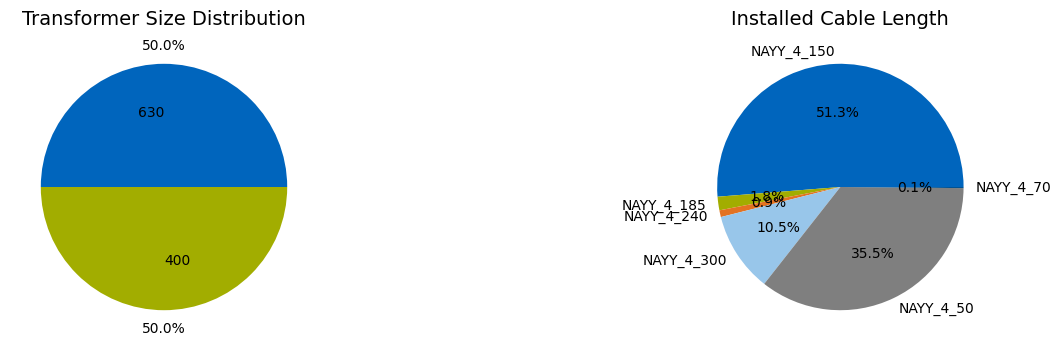

In [3]:
fig = plot_pie_of_trafo_cables(plz)

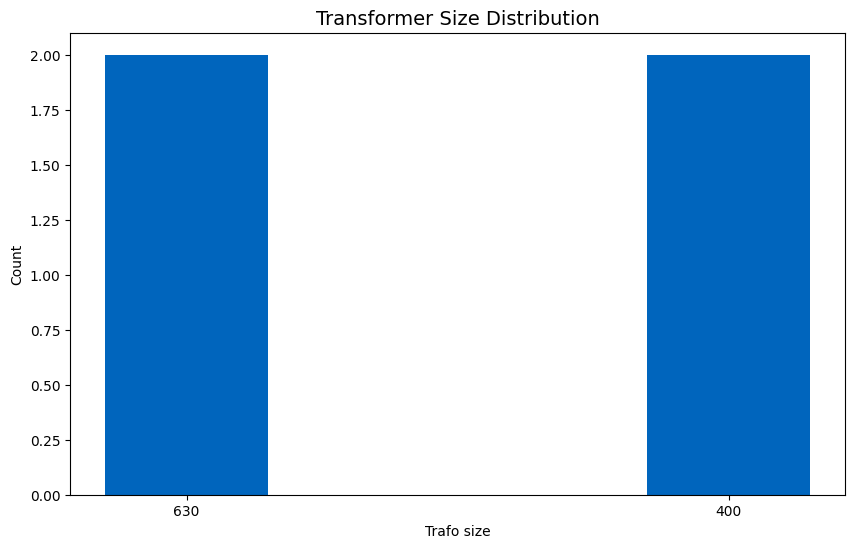

In [4]:
fig = plot_hist_trafos(plz)

## Grid parameters per transformer size

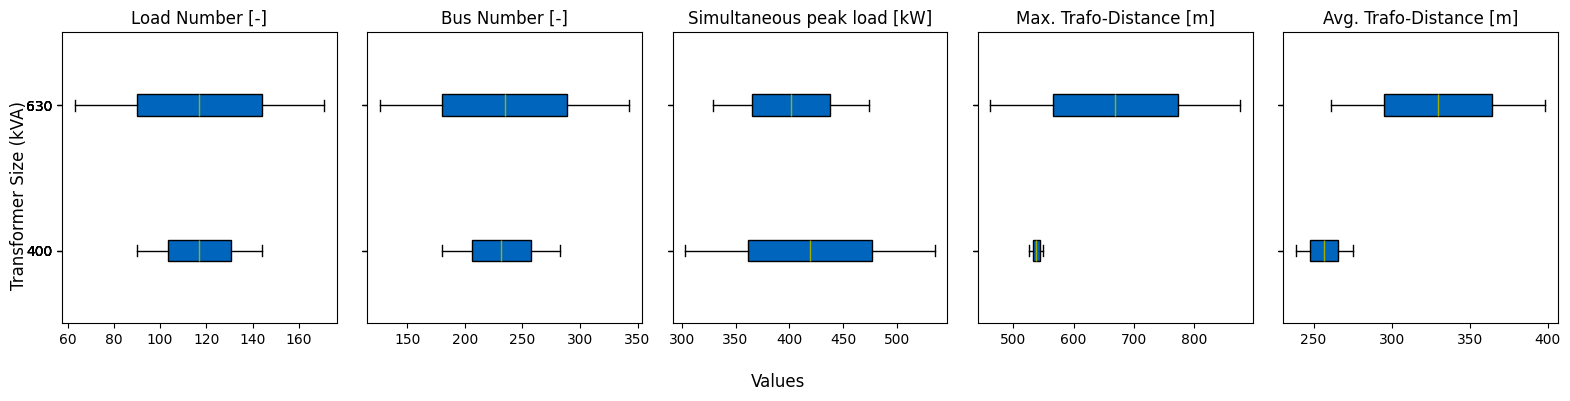

In [5]:
fig = plot_boxplot_plz(plz)

## Cable length per cable type

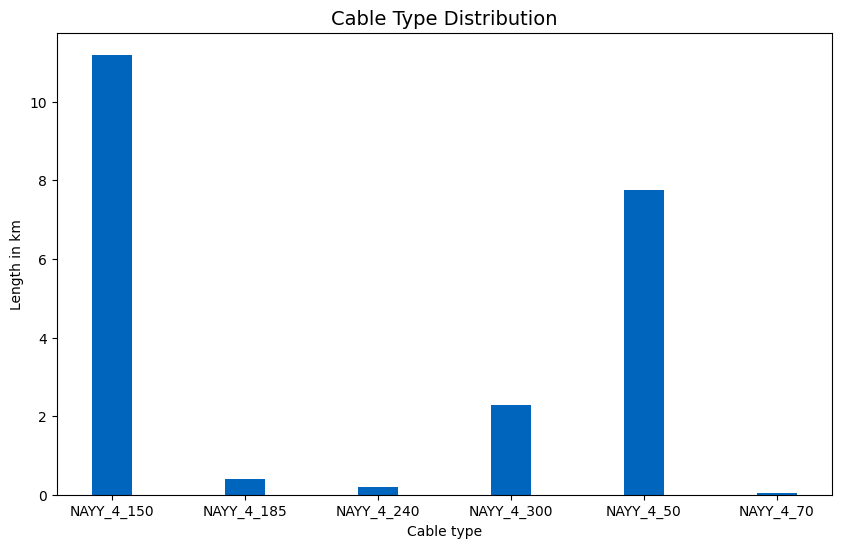

In [6]:
fig = plot_cable_length_of_types(plz)

## Transformers on a map
The transformers of the PLZ, coloured by size (`PLOT_COLOR_DICT` in `config/config_analysis.yaml`).

*Map data © OpenStreetMap contributors (ODbL).*

In [7]:
fig = plot_trafo_on_map(plz)